# **Machine Learning Project**

###**Global Air quality Dataset**





---


## Setup for the models

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

#importing libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

print(" All libraries imported successfully!")

Mounted at /content/drive
 All libraries imported successfully!


In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error
print("libraries imported!")

libraries imported!


In [ ]:
data=pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Air_Quality.csv") #dataset reading
print('data set loaded.')

data set loaded.


## Viewing data information

In [ ]:
print(f"data dimensions: {data.shape}") #row and column distribution of data

data dimensions: (52704, 10)


In [ ]:
#top 10 rows of data
data.head(10)

,Date,City,CO,CO2,NO2,SO2,O3,PM2.5,PM10,AQI
0,2024-01-01 00:00:00+00:00,Brasilia,323.0,NaN,23.8,2.8,42.0,12.0,17.1,16.800000
1,2024-01-01 01:00:00+00:00,Brasilia,318.0,NaN,21.9,2.7,40.0,12.5,17.9,16.000000
2,2024-01-01 02:00:00+00:00,Brasilia,309.0,NaN,19.2,2.6,39.0,12.1,17.3,15.599999
3,2024-01-01 03:00:00+00:00,Brasilia,295.0,NaN,16.3,2.4,38.0,11.4,16.2,15.200000
4,2024-01-01 04:00:00+00:00,Brasilia,270.0,NaN,13.0,2.1,40.0,10.2,14.6,16.000000
5,2024-01-01 05:00:00+00:00,Brasilia,239.0,NaN,9.4,1.9,44.0,8.7,12.4,17.600000
6,2024-01-01 06:00:00+00:00,Brasilia,215.0,NaN,6.8,1.7,47.0,7.5,10.7,18.800000
7,2024-01-01 07:00:00+00:00,Brasilia,205.0,NaN,6.0,1.8,46.0,6.1,8.7,18.400000
8,2024-01-01 08:00:00+00:00,Brasilia,201.0,NaN,6.1,2.1,45.0,5.7,8.2,18.000000
9,2024-01-01 09:00:00+00:00,Brasilia,199.0,NaN,5.9,2.2,46.0,5.7,8.2,18.400000


In [ ]:
print(f"--- DATA INFORMATION---\n")
data.info()

--- DATA INFORMATION---

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52704 entries, 0 to 52703
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    52704 non-null  object 
 1   City    52704 non-null  object 
 2   CO      52704 non-null  float64
 3   CO2     9648 non-null   float64
 4   NO2     52704 non-null  float64
 5   SO2     52704 non-null  float64
 6   O3      52704 non-null  float64
 7   PM2.5   52704 non-null  float64
 8   PM10    52704 non-null  float64
 9   AQI     52704 non-null  float64
dtypes: float64(8), object(2)
memory usage: 4.0+ MB


In [ ]:
print(f"--- STATS ---")
data.describe().round(3)

--- STATS ---


,CO,CO2,NO2,SO2,O3,PM2.5,PM10,AQI
count,52704.000,9648.000,52704.000,52704.000,52704.000,52704.00,52704.000,52704.000
mean,258.258,462.348,24.103,12.570,60.026,17.69,35.643,41.349
std,159.590,33.769,19.363,17.267,38.217,15.67,48.445,26.626
min,52.000,434.000,0.000,0.000,0.000,0.10,0.100,4.450
25%,159.000,445.000,9.700,2.300,35.000,6.90,10.200,22.800
50%,213.000,453.000,18.900,5.700,54.000,12.50,18.900,31.271
75%,306.000,467.000,33.400,16.800,78.000,23.00,37.500,57.702
max,2045.000,884.000,165.900,239.700,349.000,129.50,543.900,196.633




---


# DATA PREPROCESSING


---



This section includes checking for missing values, duplicate values, encoding/removing features, and one hot encoding for the categorical features.

In [ ]:
print(f"--- MISSING VALUES ---")
print(data.isnull().sum())

--- MISSING VALUES ---
Date         0
City         0
CO           0
CO2      43056
NO2          0
SO2          0
O3           0
PM2.5        0
PM10         0
AQI          0
dtype: int64


In [ ]:
data.tail(10) #last 10 rows of data set

,Date,City,CO,CO2,NO2,SO2,O3,PM2.5,PM10,AQI
52694,2024-12-31 14:00:00+00:00,Sydney,89.0,437.0,10.1,3.2,33.0,8.4,11.9,19.133333
52695,2024-12-31 15:00:00+00:00,Sydney,89.0,438.0,10.7,3.4,32.0,8.3,11.8,19.199999
52696,2024-12-31 16:00:00+00:00,Sydney,91.0,440.0,12.0,3.7,30.0,8.2,11.6,19.249998
52697,2024-12-31 17:00:00+00:00,Sydney,96.0,443.0,13.7,4.1,27.0,8.1,11.4,19.274998
52698,2024-12-31 18:00:00+00:00,Sydney,100.0,446.0,14.9,4.9,26.0,8.4,11.6,19.258331
52699,2024-12-31 19:00:00+00:00,Sydney,106.0,448.0,15.5,6.4,26.0,9.7,13.0,19.199997
52700,2024-12-31 20:00:00+00:00,Sydney,112.0,449.0,15.7,8.3,29.0,11.1,13.6,19.183330
52701,2024-12-31 21:00:00+00:00,Sydney,115.0,449.0,14.7,9.8,36.0,11.5,15.1,19.274998
52702,2024-12-31 22:00:00+00:00,Sydney,113.0,447.0,11.8,10.7,53.0,11.6,15.7,21.199999
52703,2024-12-31 23:00:00+00:00,Sydney,107.0,443.0,7.8,11.3,74.0,12.6,17.1,29.600000


In [ ]:
data.CO2.isnull().sum() #checking how many missing values are there in CO2 column

np.int64(43056)

In [ ]:
print(f"duplicate: {data.duplicated().sum()}") #duplicate data

duplicate: 0


## Checking details about the column with missing values

In [ ]:
#checking the percentage of missing data in CO2 so that we can decide whether to impute the data or drop the column entirely
# according to general rule of thumb:
# 1. <5% = impute data
# 2. 5-30% = impute carefully
# 3. 30-50% = impute if feature is imp
# 4. >50% = drop the column entirely if it doesnt affect output too much

missing = data["CO2"].isnull().sum()
total = len(data)
print(f"Missing: {missing}")
print(f"Total: {total}")
print(f"Percentage: {(missing/total)*100:.2f}%")

Missing: 43056
Total: 52704
Percentage: 81.69%


In [ ]:
print(data["CO2"].head(20))
print(data["CO2"].describe())

0    NaN
1    NaN
2    NaN
3    NaN
4    NaN
5    NaN
6    NaN
7    NaN
8    NaN
9    NaN
10   NaN
11   NaN
12   NaN
13   NaN
14   NaN
15   NaN
16   NaN
17   NaN
18   NaN
19   NaN
Name: CO2, dtype: float64
count    9648.000000
mean      462.348259
std        33.769009
min       434.000000
25%       445.000000
50%       453.000000
75%       467.000000
max       884.000000
Name: CO2, dtype: float64


In [ ]:
print(data.groupby("City")["CO2"].apply(lambda x: x.isnull().mean() * 100)) #checking whether CO2 is missing in some particular city or equally

City
Brasilia    81.693989
Cairo       81.693989
Dubai       81.693989
London      81.693989
New York    81.693989
Sydney      81.693989
Name: CO2, dtype: float64


In [ ]:
#checking whether CO2 affects our output alot or not
#correlation will tell us if CO2 is important to our target Y (AQI)
print(data[["CO2", "AQI"]].corr())

          CO2       AQI
CO2  1.000000  0.157839
AQI  0.157839  1.000000


Correlation between AQI and CO2 is 0.1578≈ 0.158, which is very small. So this means that CO2 is not very important to our output. So, we can drop the column/feature entirely.

In [ ]:

data=data.drop(columns=["CO2"])
print(f"CO2 dropped successfully!\n ")
data.head(10)

CO2 dropped successfully!
 


,Date,City,CO,NO2,SO2,O3,PM2.5,PM10,AQI
0,2024-01-01 00:00:00+00:00,Brasilia,323.0,23.8,2.8,42.0,12.0,17.1,16.800000
1,2024-01-01 01:00:00+00:00,Brasilia,318.0,21.9,2.7,40.0,12.5,17.9,16.000000
2,2024-01-01 02:00:00+00:00,Brasilia,309.0,19.2,2.6,39.0,12.1,17.3,15.599999
3,2024-01-01 03:00:00+00:00,Brasilia,295.0,16.3,2.4,38.0,11.4,16.2,15.200000
4,2024-01-01 04:00:00+00:00,Brasilia,270.0,13.0,2.1,40.0,10.2,14.6,16.000000
5,2024-01-01 05:00:00+00:00,Brasilia,239.0,9.4,1.9,44.0,8.7,12.4,17.600000
6,2024-01-01 06:00:00+00:00,Brasilia,215.0,6.8,1.7,47.0,7.5,10.7,18.800000
7,2024-01-01 07:00:00+00:00,Brasilia,205.0,6.0,1.8,46.0,6.1,8.7,18.400000
8,2024-01-01 08:00:00+00:00,Brasilia,201.0,6.1,2.1,45.0,5.7,8.2,18.000000
9,2024-01-01 09:00:00+00:00,Brasilia,199.0,5.9,2.2,46.0,5.7,8.2,18.400000


In [ ]:
print(f" --- MISSING AFTER DROPPING ---")
data.isnull().sum()

 --- MISSING AFTER DROPPING ---


,0
Date,0
City,0
CO,0
NO2,0
SO2,0
O3,0
PM2.5,0
PM10,0
AQI,0


In [ ]:
print("Duplicate rows:", data.duplicated().sum())

Duplicate rows: 0


In [ ]:
#One hot encoding to convert categorical values into numerical
data=pd.get_dummies(data, columns=["City"], dtype=int)
#dtype=int means that we would encode them in form of 0 & 1, instead of true or false.

In [ ]:
data.head(10)

,Date,CO,NO2,SO2,O3,PM2.5,PM10,AQI,City_Brasilia,City_Cairo,City_Dubai,City_London,City_New York,City_Sydney
0,2024-01-01 00:00:00+00:00,323.0,23.8,2.8,42.0,12.0,17.1,16.800000,1,0,0,0,0,0
1,2024-01-01 01:00:00+00:00,318.0,21.9,2.7,40.0,12.5,17.9,16.000000,1,0,0,0,0,0
2,2024-01-01 02:00:00+00:00,309.0,19.2,2.6,39.0,12.1,17.3,15.599999,1,0,0,0,0,0
3,2024-01-01 03:00:00+00:00,295.0,16.3,2.4,38.0,11.4,16.2,15.200000,1,0,0,0,0,0
4,2024-01-01 04:00:00+00:00,270.0,13.0,2.1,40.0,10.2,14.6,16.000000,1,0,0,0,0,0
5,2024-01-01 05:00:00+00:00,239.0,9.4,1.9,44.0,8.7,12.4,17.600000,1,0,0,0,0,0
6,2024-01-01 06:00:00+00:00,215.0,6.8,1.7,47.0,7.5,10.7,18.800000,1,0,0,0,0,0
7,2024-01-01 07:00:00+00:00,205.0,6.0,1.8,46.0,6.1,8.7,18.400000,1,0,0,0,0,0
8,2024-01-01 08:00:00+00:00,201.0,6.1,2.1,45.0,5.7,8.2,18.000000,1,0,0,0,0,0
9,2024-01-01 09:00:00+00:00,199.0,5.9,2.2,46.0,5.7,8.2,18.400000,1,0,0,0,0,0


In [ ]:
#converting date into numerics
data["Date"] = pd.to_datetime(data["Date"])
data["Year"] = data["Date"].dt.year
data["Month"] = data["Date"].dt.month
data["Day"] = data["Date"].dt.day
data["Hour"] = data["Date"].dt.hour

In [ ]:
data.drop(columns=["Date"], inplace=True)

In [ ]:
data.head(10)

,CO,NO2,SO2,O3,PM2.5,PM10,AQI,City_Brasilia,City_Cairo,City_Dubai,City_London,City_New York,City_Sydney,Year,Month,Day,Hour
0,323.0,23.8,2.8,42.0,12.0,17.1,16.800000,1,0,0,0,0,0,2024,1,1,0
1,318.0,21.9,2.7,40.0,12.5,17.9,16.000000,1,0,0,0,0,0,2024,1,1,1
2,309.0,19.2,2.6,39.0,12.1,17.3,15.599999,1,0,0,0,0,0,2024,1,1,2
3,295.0,16.3,2.4,38.0,11.4,16.2,15.200000,1,0,0,0,0,0,2024,1,1,3
4,270.0,13.0,2.1,40.0,10.2,14.6,16.000000,1,0,0,0,0,0,2024,1,1,4
5,239.0,9.4,1.9,44.0,8.7,12.4,17.600000,1,0,0,0,0,0,2024,1,1,5
6,215.0,6.8,1.7,47.0,7.5,10.7,18.800000,1,0,0,0,0,0,2024,1,1,6
7,205.0,6.0,1.8,46.0,6.1,8.7,18.400000,1,0,0,0,0,0,2024,1,1,7
8,201.0,6.1,2.1,45.0,5.7,8.2,18.000000,1,0,0,0,0,0,2024,1,1,8
9,199.0,5.9,2.2,46.0,5.7,8.2,18.400000,1,0,0,0,0,0,2024,1,1,9




---


# LINEAR REGRESSION



---



Simple Linear regression uses 1 feature and predicts target column only on the basis of that 1 column. In this section, we have used CO as our feature (x) to predict AQI (target column, y)

In [ ]:
X = data[['CO']]
y = data['AQI']

print("Input shape  (X):", X.shape) #rows and col in x
print("Output shape (y):", y.shape) #rows and col in y

Input shape  (X): (52704, 1)
Output shape (y): (52704,)


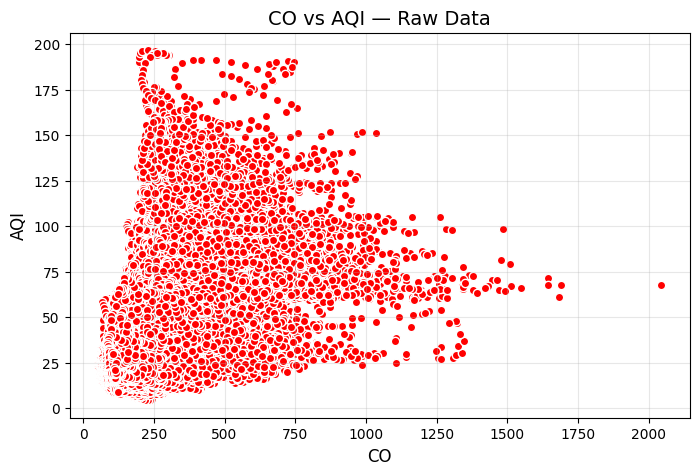

In [ ]:
#checking the relationship between target column and feature. Just by doing this we can tell if linear model will be effective or not,
# depending on the type of relationship it shows, whether it is linear or not.
plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='red', alpha=1, edgecolors='white')
plt.xlabel('CO', fontsize=12)
plt.ylabel('AQI', fontsize=12)
plt.title('CO vs AQI — Raw Data', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

As we can see, the relationship between our target column (AQI) and feature (CO) is not linear, so simple linear regression will not be very effective for our dataset. We can verify this hypothesis by the results we will get from model training.

In [ ]:
#train-test split: 80-20
#80% data: training
#20% data: testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f"Training samples : {X_train.shape[0]}")
print(f"Testing  samples : {X_test.shape[0]}")
#random_state=42 ensures same split every time you run.

Training samples : 42163
Testing  samples : 10541


In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)       # TRAIN: learn m and b from training data
print(f"Slope     (m) = {model.coef_[0]:.4f}")
print(f"Intercept (b) = {model.intercept_:.4f}")
print(f"\n Equation: AQI = {model.coef_[0]:.4f} × CO + {model.intercept_:.4f}")

# ---------------- PREDICTIONS ----------------

# Training predictions (save BEFORE X_train gets overwritten)
y_train_pred = model.predict(X_train)

# Testing predictions
y_pred = model.predict(X_test)

Slope     (m) = -0.0052
Intercept (b) = 18.1150

 Equation: AQI = -0.0052 × CO + 18.1150


In [ ]:
y_pred = model.predict(X_test)    # Predict on test data

# Show first 5 comparisons
comparison = pd.DataFrame({
    'CO amount': X_test.values.flatten(),
    'Actual AQI': y_test.values,
    'Predicted AQI': y_pred.round(2),
    'Error': (y_test.values - y_pred).round(2)
})
print("First 10 rows:")
print(comparison.head(10).to_string(index=False))

First 10 rows:
 CO amount  Actual AQI  Predicted AQI  Error
     145.0   30.400000          31.32  -0.92
     244.0   60.453335          40.21  20.24
     322.0   38.899998          47.21  -8.31
     157.0   22.925000          32.40  -9.47
     501.0   47.333336          63.28 -15.95
      85.0   18.800000          25.94  -7.14
      91.0   26.800001          26.47   0.33
     148.0   39.600000          31.59   8.01
     150.0   25.958332          31.77  -5.81
     281.0   40.666664          43.53  -2.87


In [ ]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Train metrics
mse_train = mean_squared_error(y_train, y_train_pred)
rmse_train = np.sqrt(mse_train)
mae_train = mean_absolute_error(y_train, y_train_pred)
simple_train_r2 = r2_score(y_train, y_train_pred)

print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"R²   : {r2:.4f}")

print("-"*50)
print("Overfitting Check")
print(f"Train R² : {simple_train_r2:.4f}")
print(f"Test  R² : {r2:.4f}")
print(f"Difference : {abs(simple_train_r2-r2):.4f}")

if abs(simple_train_r2-r2) < 0.05:
    print("Good generalization — no overfitting!")
elif abs(simple_train_r2-r2) < 0.15:
    print("Slight overfitting.")
else:
    print("Possible overfitting.")

print("-"*50)

if r2 >= 0.85:
    print("Good model! R² is high.")
elif r2 >= 0.6:
    print("Moderate model. Consider adding more features.")
else:
    print("Weak model. More data or features needed.")

MSE  : 108.2265
RMSE : 10.4032
MAE  : 7.4780
R²   : 0.8402
--------------------------------------------------
Overfitting Check
Train R² : 0.8391
Test  R² : 0.8402
Difference : 0.0011
Good generalization — no overfitting!
--------------------------------------------------
Moderate model. Consider adding more features.


As expected, poor results because relationship between AQI and CO was not linear, so simple linear regression doesnt work effectively for our non linear data.

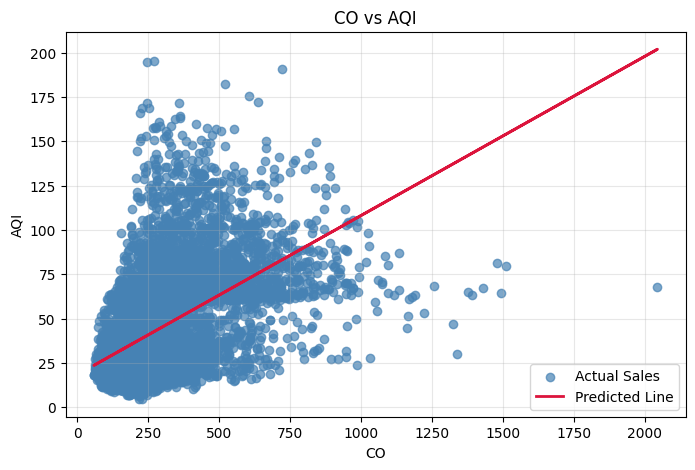

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(X_test, y_test, color='steelblue', alpha=0.7, label='Actual Sales')
plt.plot(X_test, y_pred, color='crimson', linewidth=2, label='Predicted Line')
plt.xlabel('CO')
plt.ylabel('AQI')
plt.title('CO vs AQI')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

the data points are widely dispersed around the line, which means that CO alone does not explain the variation in AQI. This suggests that AQI is influenced by multiple environmental factors rather than just one.

In [ ]:
print("--------- Linear Regression SUMMARY ----------")
print(f"  Feature used  : CO")
print(f"  Slope (m)     : {model.coef_[0]:.4f}")
print(f"  Intercept (b) : {model.intercept_:.4f}")
print(f"  R² Score      : {r2:.4f}")
print(f"  RMSE          : {rmse:.4f}")
print("---------------------------------------------")
if r2 >= 0.85:
    print(" Good model! R² is high.")
elif r2 >= 0.6:
    print("  Moderate model. Consider adding more features.")
else:
    print(" Weak model. More data or features needed.")

--------- Linear Regression SUMMARY ----------
  Feature used  : CO
  Slope (m)     : 0.0898
  Intercept (b) : 18.3051
  R² Score      : 0.2947
  RMSE          : 21.8569
---------------------------------------------
 Weak model. More data or features needed.




---

# MULTIPLE LR
---

In multiple linear regression, we use all features to predict the target column, instead of just one feature as in simple LR. So, we will be using all features to predict AQI.

In [ ]:
X = data.drop(columns=['AQI'])
y = data['AQI']

print("Features used:")
print(list(X.columns))
print("\nInput  shape:", X.shape)
print("Output shape:", y.shape)

Features used:
['CO', 'NO2', 'SO2', 'O3', 'PM2.5', 'PM10', 'City_Brasilia', 'City_Cairo', 'City_Dubai', 'City_London', 'City_New York', 'City_Sydney', 'Year', 'Month', 'Day', 'Hour']

Input  shape: (52704, 16)
Output shape: (52704,)


So we have 16 columns/features we will be using to predict AQI.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split( #80-20 split
    X, y, test_size=0.2, random_state=42)

print(f"Train: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples")

Train: 42163 samples | Test: 10541 samples


In [ ]:
model_multi = LinearRegression()
model_multi.fit(X_train, y_train)

print(" Model trained!")
print("\nLearned Weights (one per feature):")
for feat, coef in zip(X.columns, model_multi.coef_):
    print(f"  {feat:30s} → {coef:.4f}")
print("--------------------")
print(f"  {'Bias (intercept)':30s} → {model_multi.intercept_:.4f}")

 Model trained!

Learned Weights (one per feature):
  CO                             → -0.0052
  NO2                            → -0.0082
  SO2                            → 0.0802
  O3                             → 0.1215
  PM2.5                          → 0.3953
  PM10                           → 0.2185
  City_Brasilia                  → -5.5590
  City_Cairo                     → 5.1263
  City_Dubai                     → 14.1924
  City_London                    → -4.8119
  City_New York                  → -1.4600
  City_Sydney                    → -7.4879
  Year                           → 0.0000
  Month                          → 0.1007
  Day                            → -0.0217
  Hour                           → 0.1220
--------------------
  Bias (intercept)               → 18.1150


In [ ]:
y_pred_multi = model_multi.predict(X_test) #predicting new data points to check how model acts
#previously we trained model on X_train and Y_train, but now we're testing it using X_test.
mse_m  = mean_squared_error(y_test, y_pred_multi)
rmse_m = np.sqrt(mse_m)
r2_m   = r2_score(y_test, y_pred_multi)


print("  Multiple Linear Regression Performance")

print(f"  MSE  : {mse_m:.4f}")
print(f"  RMSE : {rmse_m:.4f}")
print(f"  R²   : {r2_m:.4f}")


  Multiple Linear Regression Performance
  MSE  : 108.2265
  RMSE : 10.4032
  R²   : 0.8402


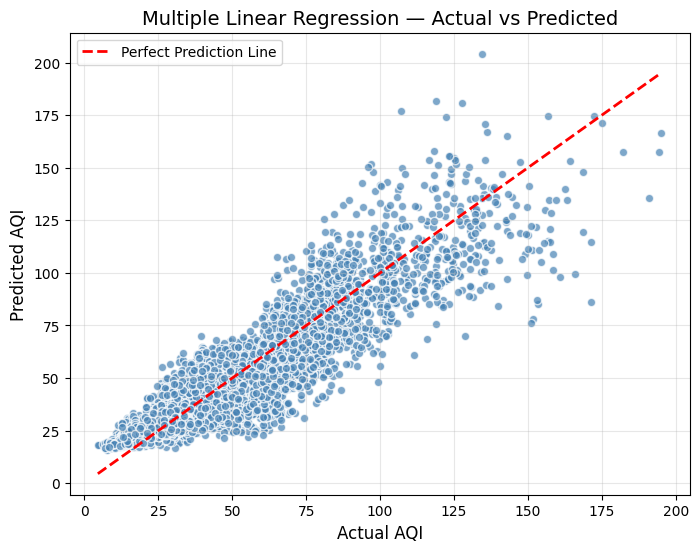

 Points close to red dashed line = accurate predictions


In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_multi, color='steelblue', alpha=0.7, edgecolors='white')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         'r--', linewidth=2, label='Perfect Prediction Line')
plt.xlabel('Actual AQI', fontsize=12)
plt.ylabel('Predicted AQI', fontsize=12)
plt.title('Multiple Linear Regression — Actual vs Predicted', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
print(" Points close to red dashed line = accurate predictions")

In [ ]:
#training vs testing
y_train_pred = model_multi.predict(X_train)
train_r2 = r2_score(y_train, y_train_pred)
test_r2  = r2_score(y_test,  y_pred_multi)

print(f"  Train R² : {train_r2:.4f}")
print(f"  Test  R² : {test_r2:.4f}")
print(f"  Difference: {abs(train_r2 - test_r2):.4f}")
print()
diff = abs(train_r2 - test_r2)
if diff < 0.05:
    print("Good generalization — no overfitting!")
elif diff < 0.15:
    print(" Slight overfitting. Could improve with more data.")
else:
    print(" Overfitting! Model memorized training data.")

  Train R² : 0.8391
  Test  R² : 0.8402
  Difference: 0.0011

Good generalization — no overfitting!


In [ ]:
# Re-run simple regression for comparison
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

X_simple = data[['CO']]
y_vals   = data['AQI']
Xs_train, Xs_test, ys_train, ys_test = train_test_split( #simple
    X_simple, y_vals, test_size=0.2, random_state=42)

m_simple = LinearRegression().fit(Xs_train, ys_train) #multiple
yp_s = m_simple.predict(Xs_test)

r2_s   = r2_score(ys_test, yp_s)
rmse_s = np.sqrt(mean_squared_error(ys_test, yp_s))

print("\n Model Comparison")
print(f"{'Model':<30} {'R² Score':>10} {'RMSE':>10}")

print(f"{'Simple ':<30} {r2_s:>10.4f} {rmse_s:>10.4f}")
print(f"{'Multiple ':<30} {r2_m:>10.4f} {rmse_m:>10.4f}")
print("\n Higher R² and lower RMSE = better model")


 Model Comparison
Model                            R² Score       RMSE
Simple                             0.2947    21.8569
Multiple                           0.8402    10.4032

 Higher R² and lower RMSE = better model


From the comparison, we can tell that multiple linear regression works alot better than simple linear regression, which proves our point that our target variable, depends on multiple features instead of 1 single feature.



---

# POLYNOMIAL REGRESSION


---



Polynomial regression works by increasing the degree of linear variables/features. Real world data isn't always linear, **polynomial regression helps us identify the non-linear relationships** between target variable and our features.

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

In [ ]:
X = data.drop(columns=['AQI'])
y = data['AQI']

print("Features used:")
print(list(X.columns))
print("\nInput  shape:", X.shape)
print("Output shape:", y.shape)

Features used:
['CO', 'NO2', 'SO2', 'O3', 'PM2.5', 'PM10', 'City_Brasilia', 'City_Cairo', 'City_Dubai', 'City_London', 'City_New York', 'City_Sydney', 'Year', 'Month', 'Day', 'Hour']

Input  shape: (52704, 16)
Output shape: (52704,)


In [ ]:
poly = PolynomialFeatures(degree=2, include_bias=False) #degree=2
X_poly = poly.fit_transform(X)

print("Original feature count :", X.shape[1])
print("Polynomial feature count:", X_poly.shape[1])
print()
print("New feature names:")
for i, name in enumerate(poly.get_feature_names_out(X.columns)):
    print(f"  [{i+1:2d}] {name}")
print()


Original feature count : 16
Polynomial feature count: 152

New feature names:
  [ 1] CO
  [ 2] NO2
  [ 3] SO2
  [ 4] O3
  [ 5] PM2.5
  [ 6] PM10
  [ 7] City_Brasilia
  [ 8] City_Cairo
  [ 9] City_Dubai
  [10] City_London
  [11] City_New York
  [12] City_Sydney
  [13] Year
  [14] Month
  [15] Day
  [16] Hour
  [17] CO^2
  [18] CO NO2
  [19] CO SO2
  [20] CO O3
  [21] CO PM2.5
  [22] CO PM10
  [23] CO City_Brasilia
  [24] CO City_Cairo
  [25] CO City_Dubai
  [26] CO City_London
  [27] CO City_New York
  [28] CO City_Sydney
  [29] CO Year
  [30] CO Month
  [31] CO Day
  [32] CO Hour
  [33] NO2^2
  [34] NO2 SO2
  [35] NO2 O3
  [36] NO2 PM2.5
  [37] NO2 PM10
  [38] NO2 City_Brasilia
  [39] NO2 City_Cairo
  [40] NO2 City_Dubai
  [41] NO2 City_London
  [42] NO2 City_New York
  [43] NO2 City_Sydney
  [44] NO2 Year
  [45] NO2 Month
  [46] NO2 Day
  [47] NO2 Hour
  [48] SO2^2
  [49] SO2 O3
  [50] SO2 PM2.5
  [51] SO2 PM10
  [52] SO2 City_Brasilia
  [53] SO2 City_Cairo
  [54] SO2 City_Dubai
  [55

In [ ]:
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split( #80-20 split
    X_poly, y, test_size=0.2, random_state=42)

print(f"Train: {X_train_p.shape} \n Test: {X_test_p.shape}")

Train: (42163, 152) 
 Test: (10541, 152)


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler_p = StandardScaler() #scaling so that a single feature doesn't dominate
X_train_p_scaled = scaler_p.fit_transform(X_train_p)
X_test_p_scaled  = scaler_p.transform(X_test_p)

y_train_arr = y_train_p.values
y_test_arr  = y_test_p.values

print(" Scaling applied to", X_train_p_scaled.shape[1], "polynomial features")
print(f"Before scaling — max value in X_train: {X_train_p.max().max():.1f}")
print(f"After  scaling — max value in X_train: {X_train_p_scaled.max():.4f}")

 Scaling applied to 152 polynomial features
Before scaling — max value in X_train: 4096576.0
After  scaling — max value in X_train: 34.6752


Feature scaling is important for models such as Polynomial Regression, KNN, and SVR because features with larger numerical values can dominate those with smaller values. Scaling places all features on a similar range, allowing the model to treat each feature fairly and produce more accurate predictions.

In [ ]:
n_samples, n_feats = X_train_p_scaled.shape
#initializing:
weights_p = np.zeros(n_feats)  #weights
bias_p    = 0 #bias
lr_p      = 0.01 #learning rate
epochs_p  = 2000 #iterations
losses_p  = []

for epoch in range(epochs_p):
    y_pred_p = np.dot(X_train_p_scaled, weights_p) + bias_p #y^ (pred) = wx +b
    error_p  = y_train_arr - y_pred_p #error = actual - pred = y - y^
    #calulate gradients:
    dw = (-1/n_samples) * np.dot(X_train_p_scaled.T, error_p) # -(1/n)∑(error)(x)
    db = (-1/n_samples) * np.sum(error_p)# -(1/n)∑(error)
    #updation:
    #new = old - (learning_rate)(gradient)
    weights_p -= lr_p * dw
    bias_p    -= lr_p * db
    #MSE/loss
    losses_p.append(np.mean(error_p**2)) #-(1/n)∑(actual-predicted)^2

print(f" Training complete! Final Loss: {losses_p[-1]:.4f}")

 Training complete! Final Loss: 85.4530


In [ ]:
y_pred_poly = np.dot(X_test_p_scaled, weights_p) + bias_p #predictions for test data using eq: y^ = wx+b

mse_p  = np.mean((y_test_arr - y_pred_poly)**2) #error= y_test_arr - y_pred_poly
ss_tot = np.sum((y_test_arr - np.mean(y_test_arr))**2) #total sum of sq = ∑(actual - mean)^2
ss_res = np.sum((y_test_arr - y_pred_poly)**2) #residual sum of sq= ∑(actual-pred)^2
r2_p   = 1 - ss_res/ss_tot

# ---------------- TRAINING PERFORMANCE ----------------
y_train_pred_poly = np.dot(X_train_p_scaled, weights_p) + bias_p

mse_train_p = np.mean((y_train_arr - y_train_pred_poly)**2)
ss_tot_train = np.sum((y_train_arr - np.mean(y_train_arr))**2)
ss_res_train = np.sum((y_train_arr - y_train_pred_poly)**2)
poly_train_r2 = 1 - (ss_res_train / ss_tot_train)

print("  Polynomial Regression (Degree 2) Results")

print(f"  MSE    : {mse_p:.4f}")
print(f"  RMSE   : {np.sqrt(mse_p):.4f}")
print(f"  R²     : {r2_p:.4f}")
print("-"*50)
print("Overfitting Check")
print(f"Train R² : {poly_train_r2:.4f}")
print(f"Test  R² : {r2_p:.4f}")
print(f"Difference : {abs(poly_train_r2-r2_p):.4f}")
print("-"*50)
if abs(poly_train_r2-r2_p) < 0.05:
    print("Good generalization — no overfitting!")
elif abs(poly_train_r2-r2_p) < 0.15:
    print("Slight overfitting.")
else:
    print("Possible overfitting.")

if r2_p >= 0.85:
    print(" Good model! R² is high.")
elif r2_p >= 0.6:
    print("  Moderate model. Consider adding more features.")
else:
    print(" Weak model. More data or features needed.")

  Polynomial Regression (Degree 2) Results
  MSE    : 79.6185
  RMSE   : 8.9229
  R²     : 0.8825
--------------------------------------------------
Overfitting Check
Train R² : 0.8808
Test  R² : 0.8825
Difference : 0.0017
--------------------------------------------------
Good generalization — no overfitting!
 Good model! R² is high.


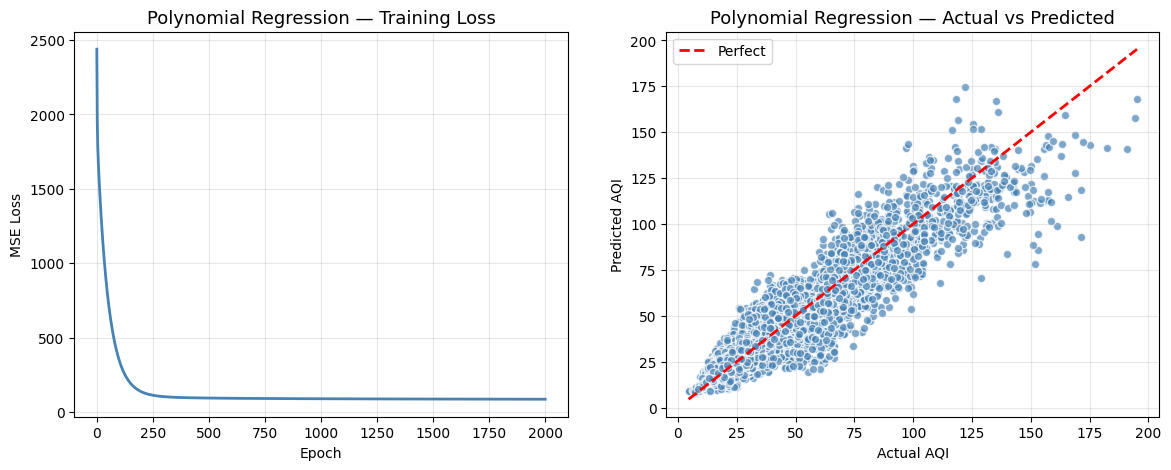

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
axes[0].plot(losses_p, color='steelblue', linewidth=2)
axes[0].set_title('Polynomial Regression — Training Loss', fontsize=13)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE Loss')
axes[0].grid(True, alpha=0.3)

# Actual vs Predicted
axes[1].scatter(y_test_arr, y_pred_poly, color='steelblue', alpha=0.7, edgecolors='white')
axes[1].plot([y_test_arr.min(), y_test_arr.max()],
             [y_test_arr.min(), y_test_arr.max()], 'r--', linewidth=2, label='Perfect')
axes[1].set_xlabel('Actual AQI')
axes[1].set_ylabel('Predicted AQI')
axes[1].set_title('Polynomial Regression — Actual vs Predicted', fontsize=13)
axes[1].legend(); axes[1].grid(True, alpha=0.3)


plt.show()



---

#DECISION TREE


---



Decision tree is an algorithm which learns from a series of if-else questions. it basically splits data and forms a tree based on those if-else questions. Decision Trees can capture non-linear relationships.

In [ ]:
X_multi = data.drop(columns=['AQI'])
y_multi = data['AQI']

print("Input shape  (X_multi):", X_multi.shape)
print("Output shape (y_multi):", y_multi.shape)

#80-20 split
X_train, X_test, y_train, y_test = train_test_split(
    X_multi, y_multi, test_size=0.2, random_state=42
)

print(f"Training samples : {X_train.shape[0]}")
print(f"Testing  samples : {X_test.shape[0]}")

# max_depth=10 is used to help keep the tree from over-expanding and overfitting
dt_model = DecisionTreeRegressor(random_state=42, max_depth=10)
dt_model.fit(X_train, y_train)
print("Decision Tree Model trained successfully!")

Input shape  (X_multi): (52704, 16)
Output shape (y_multi): (52704,)
Training samples : 42163
Testing  samples : 10541
Decision Tree Model trained successfully!


In [ ]:
#Predictions on Test and Train Data
dt_pred = dt_model.predict(X_test)
dt_train_pred = dt_model.predict(X_train)  # Needed for overfitting check

In [ ]:
#Comparison (First 10 Rows)
dt_comparison = pd.DataFrame({
    'Actual AQI': y_test.values,
    'Predicted AQI': dt_pred.round(2),
    'Error': (y_test.values - dt_pred).round(2)
})
print("\nFirst 10 rows of Decision Tree Predictions:")
print(dt_comparison.head(10).to_string(index=False))


First 10 rows of Decision Tree Predictions:
 Actual AQI  Predicted AQI  Error
  30.400000          31.36  -0.96
  60.453335          41.98  18.47
  38.899998          38.38   0.52
  22.925000          18.14   4.78
  47.333336          47.03   0.30
  18.800000          20.84  -2.04
  26.800001          27.31  -0.51
  39.600000          38.94   0.66
  25.958332          27.48  -1.52
  40.666664          51.23 -10.56


In [ ]:
#Evaluation Metrics
dt_mse  = mean_squared_error(y_test, dt_pred)
dt_rmse = np.sqrt(dt_mse)
dt_r2   = r2_score(y_test, dt_pred)
dt_mae  = mean_absolute_error(y_test, dt_pred)

dt_train_r2 = r2_score(y_train, dt_train_pred)
dt_train_rmse = np.sqrt(mean_squared_error(y_train, dt_train_pred))

print("              DECISION TREE RESULTS              ")

print(f"  DT MSE  (Mean Squared Error) : {dt_mse:.4f}")
print(f"  DT RMSE (Root MSE)           : {dt_rmse:.4f}")
print(f"  DT R²   (R-squared Score)    : {dt_r2:.4f}")
print(f"  DT MAE  (Mean Absolute Error): {dt_mae:.4f}")
print("-" * 50)
print("         OVERFITTING CHECK (TRAIN VS TEST)       ")
print("-" * 50)
print(f"  Train R²   : {dt_train_r2:.4f}  \n  Test R²   : {dt_r2:.4f}")
print(f"  Train RMSE : {dt_train_rmse:.4f}  \n  Test RMSE : {dt_rmse:.4f}")
print(f"  R² Gap     : {(dt_train_r2 - dt_r2):.4f}")


if (dt_train_r2 - dt_r2) > 0.10:
    print(" WARNING: Model might be OVERFITTING! Train performance is significantly higher than Test.")
else:
    print(" Generalization Check Passed! The model is well-balanced.")
print("-"*50)
if dt_r2 >= 0.85:
    print(" Good model! R² is high.")
elif dt_r2 >= 0.6:
    print("  Moderate model. Consider tuning max_depth or using an ensemble.")
else:
    print(" Weak model. More features or structural pruning needed.")


              DECISION TREE RESULTS              
  DT MSE  (Mean Squared Error) : 60.4317
  DT RMSE (Root MSE)           : 7.7738
  DT R²   (R-squared Score)    : 0.9108
  DT MAE  (Mean Absolute Error): 4.5845
--------------------------------------------------
         OVERFITTING CHECK (TRAIN VS TEST)       
--------------------------------------------------
  Train R²   : 0.9336  
  Test R²   : 0.9108
  Train RMSE : 6.8963  
  Test RMSE : 7.7738
  R² Gap     : 0.0229
 Generalization Check Passed! The model is well-balanced.
--------------------------------------------------
 Good model! R² is high.


/tmp/ipykernel_4449/3127732451.py:5: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, color='crimson', label='Perfect Fit')


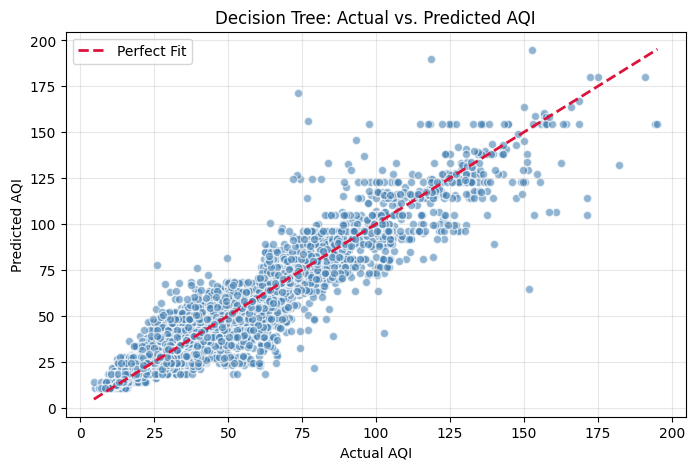

In [ ]:
#Actual vs. Predicted Plot
plt.figure(figsize=(8, 5))
plt.scatter(y_test, dt_pred, color='steelblue', alpha=0.6, edgecolors='white')

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, color='crimson', label='Perfect Fit')
plt.xlabel('Actual AQI')
plt.ylabel('Predicted AQI')
plt.title('Decision Tree: Actual vs. Predicted AQI')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()



---
# RANDOM FOREST


---




Random forest combines predictions of multiple decision trees.

**Decision trees --> high variance, low bias**

**Random Forest --> low variance, low bias**

Random forest combines many decision trees, and when they are combined their variance reduces overall, without modifying bias too much.

In [ ]:

X_multi = data.drop(columns=['AQI'])
y_multi = data['AQI']

print("Input shape  (X_multi):", X_multi.shape)
print("Output shape (y_multi):", y_multi.shape)

#80-20 split
X_train, X_test, y_train, y_test = train_test_split(
    X_multi, y_multi, test_size=0.2, random_state=42
)

print(f"Training samples : {X_train.shape[0]}")
print(f"Testing  samples : {X_test.shape[0]}")

Input shape  (X_multi): (52704, 16)
Output shape (y_multi): (52704,)
Training samples : 42163
Testing  samples : 10541


In [ ]:

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
print("Random Forest Model trained successfully!")

Random Forest Model trained successfully!


In [ ]:
#predictions for test and training sets
rf_train_pred = rf_model.predict(X_train)
rf_test_pred = rf_model.predict(X_test)

In [ ]:
rf_comparison = pd.DataFrame({
    'Actual AQI': y_test.values,
    'Predicted AQI': rf_test_pred.round(2),
    'Error': (y_test.values - rf_test_pred).round(2)
})
print("\nFirst 10 rows of Random Forest Predictions:")
print(rf_comparison.head(10).to_string(index=False))


First 10 rows of Random Forest Predictions:
 Actual AQI  Predicted AQI  Error
  30.400000          30.62  -0.22
  60.453335          54.89   5.56
  38.899998          39.09  -0.19
  22.925000          21.35   1.58
  47.333336          47.70  -0.37
  18.800000          19.29  -0.49
  26.800001          27.11  -0.31
  39.600000          39.60   0.00
  25.958332          24.81   1.15
  40.666664          43.83  -3.17


In [ ]:
#evaluation metrics
rf_mse  = mean_squared_error(y_test, rf_test_pred)
rf_rmse = np.sqrt(rf_mse)
rf_mae  = mean_absolute_error(y_test, rf_test_pred)
rf_r2   = r2_score(y_test, rf_test_pred)

# Metrics on Training Data
rf_train_r2 = r2_score(y_train, rf_train_pred)
rf_train_rmse = np.sqrt(mean_squared_error(y_train, rf_train_pred))

print("              RANDOM FOREST RESULTS              ")
print(f"  Test MAE   : {rf_mae:.4f}")
print(f"  Test RMSE  : {rf_rmse:.4f}")
print(f"  Test R²    : {rf_r2:.4f}")
print("-" * 50)
print("         OVERFITTING CHECK (TRAIN VS TEST)       ")

print(f"  Train R²   : {rf_train_r2:.4f}  |  Test R²   : {rf_r2:.4f}")
print(f"  Train RMSE : {rf_train_rmse:.4f}  |  Test RMSE : {rf_rmse:.4f}")
print(f"  R² Variance: {abs(rf_train_r2 - rf_r2):.4f}")
print("-" * 50)
if (rf_train_r2 - rf_r2) > 0.10:
    print(" WARNING: Model might be OVERFITTING! Train performance is significantly higher than Test.")
else:
    print(" Generalization Check Passed! The model is well-balanced.")

if rf_r2 >= 0.85:
    print(" Good model! R² is high.")
elif rf_r2 >= 0.6:
    print("  Moderate model. Consider tuning hyperparameters.")
else:
    print(" Weak model. More data or engineering needed.")

              RANDOM FOREST RESULTS              
  Test MAE   : 3.1383
  Test RMSE  : 5.4946
  Test R²    : 0.9554
--------------------------------------------------
         OVERFITTING CHECK (TRAIN VS TEST)       
  Train R²   : 0.9936  |  Test R²   : 0.9554
  Train RMSE : 2.1449  |  Test RMSE : 5.4946
  R² Variance: 0.0382
--------------------------------------------------
 Generalization Check Passed! The model is well-balanced.
 Good model! R² is high.


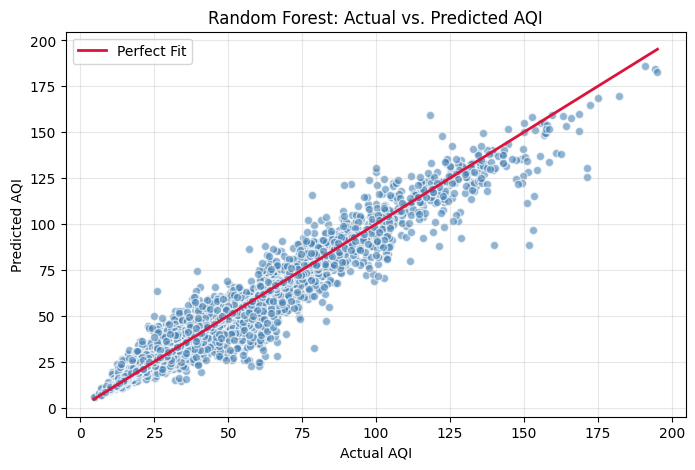

In [ ]:
#Actual vs. Predicted Plot
plt.figure(figsize=(8, 5))
plt.scatter(y_test, rf_test_pred, color='steelblue', alpha=0.6, edgecolors='white')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], lw=2, color='crimson', label='Perfect Fit')
plt.xlabel('Actual AQI')
plt.ylabel('Predicted AQI')
plt.title('Random Forest: Actual vs. Predicted AQI')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()



---

# KNN


---



it uses distance to identify neighbors, feature scaling is important for accurate predictions.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)
print("KNN Model trained successfully!")

KNN Model trained successfully!


In [ ]:
#predictions on training and testing data
knn_train_pred = knn_model.predict(X_train_scaled)
knn_test_pred = knn_model.predict(X_test_scaled)

In [ ]:
#Comparison (First 10 Rows on Test Data)
knn_comparison = pd.DataFrame({
    'Actual AQI': y_test.values,
    'Predicted AQI': knn_test_pred.round(2),
    'Error': (y_test.values - knn_test_pred).round(2)
})
print("\nFirst 10 rows of KNN Predictions:")
print(knn_comparison.head(10).to_string(index=False))


First 10 rows of KNN Predictions:
 Actual AQI  Predicted AQI  Error
  30.400000          29.20   1.20
  60.453335          59.76   0.70
  38.899998          36.48   2.42
  22.925000          23.16  -0.23
  47.333336          49.78  -2.45
  18.800000          18.72   0.08
  26.800001          26.56   0.24
  39.600000          38.45   1.15
  25.958332          26.90  -0.94
  40.666664          41.42  -0.76


In [ ]:
#Evaluation Metrics
knn_mse  = mean_squared_error(y_test, knn_test_pred)
knn_rmse = np.sqrt(knn_mse)
knn_mae  = mean_absolute_error(y_test, knn_test_pred)
knn_r2   = r2_score(y_test, knn_test_pred)

In [ ]:
#evaluation metrics on training data
knn_train_r2 = r2_score(y_train, knn_train_pred)
knn_train_rmse = np.sqrt(mean_squared_error(y_train, knn_train_pred))

print("              KNN REGRESSOR RESULTS              ")

print(f"  Test MAE   : {knn_mae:.4f}")
print(f"  Test RMSE  : {knn_rmse:.4f}")
print(f"  Test R²    : {knn_r2:.4f}")
print("-" * 50)
print("         OVERFITTING CHECK (TRAIN VS TEST)       ")
print("-" * 50)
print(f"  Train R²   : {knn_train_r2:.4f}  |  Test R²   : {knn_r2:.4f}")
print(f"  Train RMSE : {knn_train_rmse:.4f}  |  Test RMSE : {knn_rmse:.4f}")
print(f"  R² Variance: {abs(knn_train_r2 - knn_r2):.4f}")
print("-" * 50)

if (knn_train_r2 - knn_r2) > 0.10:
    print(" WARNING: Model might be OVERFITTING! Train performance is significantly higher than Test.")
else:
    print(" Generalization Check Passed! The model is well-balanced.")


if knn_r2 >= 0.85:
    print(" Good model! R² is high.")
elif knn_r2 >= 0.6:
    print("  Moderate model. Consider tuning hyperparameters.")
else:
    print(" Weak model. More data or engineering needed.")

              KNN REGRESSOR RESULTS              
  Test MAE   : 3.4351
  Test RMSE  : 5.8624
  Test R²    : 0.9493
--------------------------------------------------
         OVERFITTING CHECK (TRAIN VS TEST)       
--------------------------------------------------
  Train R²   : 0.9693  |  Test R²   : 0.9493
  Train RMSE : 4.6927  |  Test RMSE : 5.8624
  R² Variance: 0.0200
--------------------------------------------------
 Generalization Check Passed! The model is well-balanced.
 Good model! R² is high.


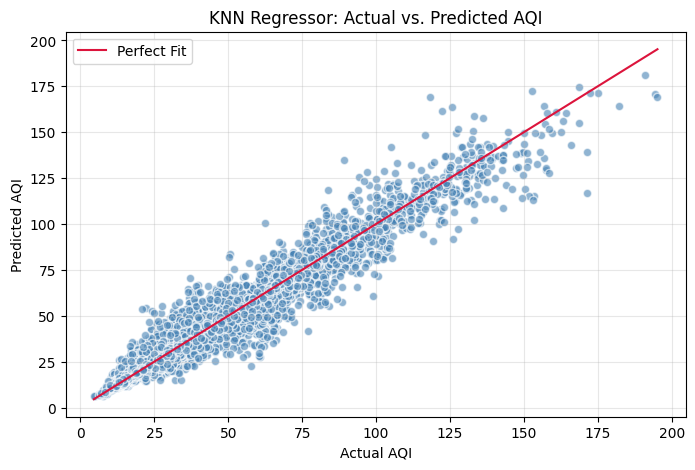

In [ ]:
#Actual vs. Predicted Plot
plt.figure(figsize=(8, 5))
plt.scatter(y_test, knn_test_pred, color='steelblue', alpha=0.6, edgecolors='white')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='crimson', label='Perfect Fit')
plt.xlabel('Actual AQI')
plt.ylabel('Predicted AQI')
plt.title('KNN Regressor: Actual vs. Predicted AQI')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()



---

# SVR


---



Support Vector Regression is a regression algorithm that predicts continuous values by finding a function that best fits the data while keeping prediction errors within a specified margin.

In [ ]:
from sklearn.svm import SVR

In [ ]:
# Setting max_iter=5000 stops the quadratic loop early so it finishes in seconds
svr_model = SVR(kernel='rbf', C=100.0, epsilon=0.1, max_iter=5000)
svr_model.fit(X_train_scaled, y_train)
print("SVR Model trained successfully!")

SVR Model trained successfully!


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


In [ ]:
#predictions on both testing and training data
svr_train_pred = svr_model.predict(X_train_scaled)
svr_test_pred = svr_model.predict(X_test_scaled)

In [ ]:
#Comparison (First 10 Rows on Test Data)
svr_comparison = pd.DataFrame({
    'Actual AQI': y_test.values,
    'Predicted AQI': svr_test_pred.round(2),
    'Error': (y_test.values - svr_test_pred).round(2)
})
print("\nFirst 10 rows of SVR Predictions:")
print(svr_comparison.head(10).to_string(index=False))


First 10 rows of SVR Predictions:
 Actual AQI  Predicted AQI  Error
  30.400000          29.07   1.33
  60.453335          38.12  22.33
  38.899998          42.26  -3.36
  22.925000          21.61   1.32
  47.333336          42.81   4.52
  18.800000          14.95   3.85
  26.800001          28.85  -2.05
  39.600000          36.93   2.67
  25.958332          19.68   6.28
  40.666664          35.68   4.99


In [ ]:
#evaluation metrics
svr_mse  = mean_squared_error(y_test, svr_test_pred)
svr_rmse = np.sqrt(svr_mse)
svr_mae  = mean_absolute_error(y_test, svr_test_pred)
svr_r2   = r2_score(y_test, svr_test_pred)

# Metrics on Training Data
svr_train_r2 = r2_score(y_train, svr_train_pred)
svr_train_rmse = np.sqrt(mean_squared_error(y_train, svr_train_pred))


print("            SUPPORT VECTOR REGRESSOR RESULTS     ")

print(f"  Test MAE   : {svr_mae:.4f}")
print(f"  Test RMSE  : {svr_rmse:.4f}")
print(f"  Test R²    : {svr_r2:.4f}")
print("-" * 50)
print("         OVERFITTING CHECK (TRAIN VS TEST)       ")
print("-" * 50)
print(f"  Train R²   : {svr_train_r2:.4f}  |  Test R²   : {svr_r2:.4f}")
print(f"  Train RMSE : {svr_train_rmse:.4f}  |  Test RMSE : {svr_rmse:.4f}")
print(f"  R² Variance: {abs(svr_train_r2 - svr_r2):.4f}")
print("-" * 50)

if (svr_train_r2 - svr_r2) > 0.10:
    print(" WARNING: Model might be OVERFITTING! Train performance is significantly higher than Test.")
else:
    print(" Generalization Check Passed! The model is well-balanced.")
print("-" * 50)
if svr_r2 >= 0.85:
    print(" Good model! R² is high.")
elif svr_r2 >= 0.6:
    print("  Moderate model. Consider tuning hyperparameters.")
else:
    print(" Weak model. More data or engineering needed.")

            SUPPORT VECTOR REGRESSOR RESULTS     
  Test MAE   : 6.6538
  Test RMSE  : 9.2123
  Test R²    : 0.8747
--------------------------------------------------
         OVERFITTING CHECK (TRAIN VS TEST)       
--------------------------------------------------
  Train R²   : 0.8813  |  Test R²   : 0.8747
  Train RMSE : 9.2231  |  Test RMSE : 9.2123
  R² Variance: 0.0066
--------------------------------------------------
 Generalization Check Passed! The model is well-balanced.
--------------------------------------------------
 Good model! R² is high.


/tmp/ipykernel_4449/4284937143.py:4: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, color='crimson', label='Perfect Fit')


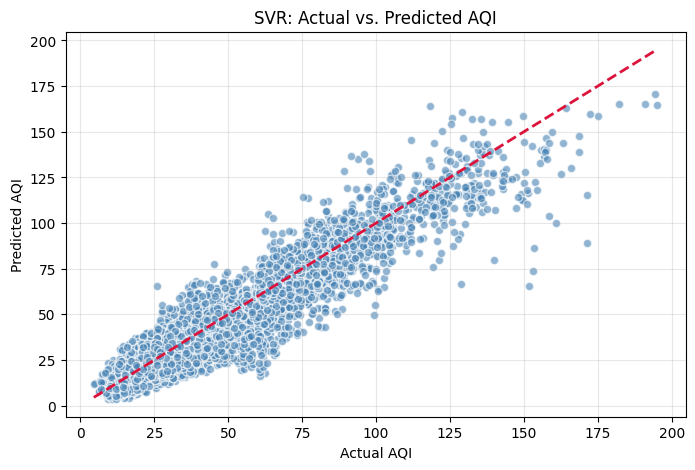

In [ ]:
#Actual vs. Predicted Plot
plt.figure(figsize=(8, 5))
plt.scatter(y_test, svr_test_pred, color='steelblue', alpha=0.6, edgecolors='white')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, color='crimson', label='Perfect Fit')
plt.xlabel('Actual AQI')
plt.ylabel('Predicted AQI')
plt.title('SVR: Actual vs. Predicted AQI')
plt.grid(True, alpha=0.3)
plt.show()



---

# MODEL COMPARISON


---



In [ ]:

summary_data = {
    "Model": [
        "Simple LR (CO Only)",
        "Multiple LR",
        "Polynomial LR",
        "Decision Tree",
        "Random Forest",
        "KNN",
        "SVR"
    ],

    "Test MAE": [
        mae,
        mean_absolute_error(y_test, y_pred_multi),
        mean_absolute_error(y_test_p, y_pred_poly),
        dt_mae,
        rf_mae,
        knn_mae,
        svr_mae
    ],

    "Test RMSE": [
        rmse,
        rmse_m,
        np.sqrt(mse_p),
        dt_rmse,
        rf_rmse,
        knn_rmse,
        svr_rmse
    ],

    "Test R²": [
        r2,
        r2_m,
        r2_p,
        dt_r2,
        rf_r2,
        knn_r2,
        svr_r2
    ],

    "Train R²": [
        simple_train_r2,
        train_r2,          # Fixed variable name from multi_train_r2
        poly_train_r2,
        dt_train_r2,
        rf_train_r2,
        knn_train_r2,
        svr_train_r2
    ],

    "Overfitting Risk": [
        "High" if (simple_train_r2 - r2) > 0.10 else "Low",
        "High" if (train_r2 - r2_m) > 0.10 else "Low",       # Fixed variable name
        "High" if (poly_train_r2 - r2_p) > 0.10 else "Low",
        "High" if (dt_train_r2 - dt_r2) > 0.10 else "Low",
        "High" if (rf_train_r2 - rf_r2) > 0.10 else "Low",
        "High" if (knn_train_r2 - knn_r2) > 0.10 else "Low",
        "High" if (svr_train_r2 - svr_r2) > 0.10 else "Low"
    ]
}

df_summary = pd.DataFrame(summary_data)

print("-" * 100)
print("                 FINAL PERFORMANCE COMPARISON")
print("-" * 100)
# Formatted to display floating points neatly up to 4 decimals
print(df_summary.to_string(index=False, float_format=lambda x: f"{x:.4f}" if isinstance(x, float) else str(x)))
print("-" * 100)

----------------------------------------------------------------------------------------------------
                 FINAL PERFORMANCE COMPARISON
----------------------------------------------------------------------------------------------------
              Model  Test MAE  Test RMSE  Test R²  Train R² Overfitting Risk
Simple LR (CO Only)    7.4780    10.4032   0.8402    0.8391              Low
        Multiple LR    7.4780    10.4032   0.8402    0.8391              Low
      Polynomial LR    6.0156     8.9229   0.8825    0.8808              Low
      Decision Tree    4.5845     7.7738   0.9108    0.9336              Low
      Random Forest    3.1383     5.4946   0.9554    0.9936              Low
                KNN    3.4351     5.8624   0.9493    0.9693              Low
                SVR    6.6538     9.2123   0.8747    0.8813              Low
----------------------------------------------------------------------------------------------------


From our final model comparison, we can tell random forest has the highest R2 score and lowest RMSE which means it performs the best for our data set overall.